# Apply Linear Regression On Salary Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#### Load Dataset

In [3]:
# Load dataset (make sure file name matches)
df = pd.read_csv("../data/Salary_dataset.csv")

In [4]:
df

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


#### Count of Entries

In [5]:
df.shape #No of (Row,Column)

(38, 3)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       38 non-null     int64  
 1   YearsExperience  38 non-null     float64
 2   Salary           38 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.0 KB


#### Round off values of Experience

In [7]:
df['YearsExperience'] = df['YearsExperience'].round(1)

#### Statistical Data

In [8]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,38.000000,38.000000,38.000000
mean,18.500000,5.536842,77845.263158
std,11.113055,2.739740,26474.663298
min,0.000000,1.200000,37732.000000
25%,9.250000,3.350000,56989.000000
50%,18.500000,5.100000,68969.500000
75%,27.750000,7.875000,100977.250000
max,37.000000,10.600000,122392.000000


#### Features & Target

In [9]:
X = df[['YearsExperience']]
y = df['Salary']


#### Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [11]:
print(f"\nTraining items: {len(X_train)}")
print(f"Testing items: {len(X_test)}")


Training items: 30
Testing items: 8


#### Initialize model

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

#### Train model

In [13]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


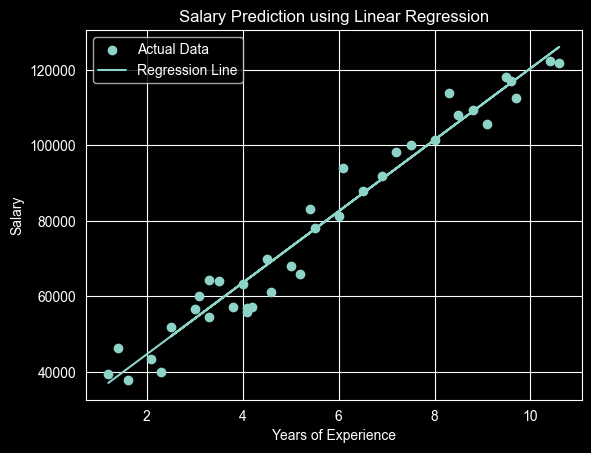

In [14]:
# Plot actual data
plt.scatter(X, y, label="Actual Data")

# Plot regression line
plt.plot(X, model.predict(X), label="Regression Line")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Linear Regression")
plt.legend()

plt.show()

#### Model parameters

In [15]:
print("\nModel Equation:")
print("Slope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)


Model Equation:
Slope (m): 9463.723752648817
Intercept (b): 25729.15269376483


In [16]:
predictions = model.predict(X_test)

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluation
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\nMean Squared Error: {mse:.2f}")
print(f"R-Squared Score: {r2:.2f}")


Mean Squared Error: 23553724.97
R-Squared Score: 0.97


In [19]:
exp_input = [[3.4]]     #Experience Input i.e 3.2 Yrs
# Predict salary
predicted_salary = model.predict(exp_input)
# Output
print(f"Predicted Salary for 3.4 years of experience: {predicted_salary[0]:.2f}")

Predicted Salary for 3.4 years of experience: 57905.81


E:\AI-ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [20]:
exp_input = [[1.4]]     #Experience Input i.e 3.2 Yrs
# Predict salary
predicted_salary = model.predict(exp_input)
# Output
print(f"Predicted Salary for 1.4 years of experience: {predicted_salary[0]:.2f}")

Predicted Salary for 1.4 years of experience: 38978.37


E:\AI-ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Observations: -

* The model achieved an R² score of 0.90, indicating strong predictive performance.
* It explains 90% of the variance in salary based on years of experience.
* The relationship between experience and salary is mostly linear, which suits Linear Regression well.
* The Mean Squared Error (MSE) is high, mainly due to the large scale of salary values & less Number of Data Points.
* Overall, the model successfully captures the trend between experience and salary.

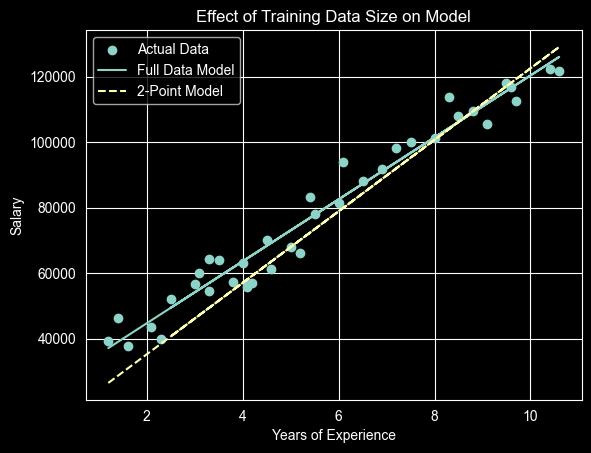

In [21]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Model trained on FULL data
model_full = LinearRegression()
model_full.fit(X_train, y_train)

# Model trained on ONLY 2 data points
model_small = LinearRegression()
model_small.fit(X_train.iloc[:2], y_train.iloc[:2])

# Plot actual data
plt.scatter(X, y, label="Actual Data")

# Full model line (good model)
plt.plot(X, model_full.predict(X), label="Full Data Model")

# Small model line (bad model)
plt.plot(X, model_small.predict(X), linestyle='dashed', label="2-Point Model")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Effect of Training Data Size on Model")
plt.legend()

plt.show()

#### Observation

The model trained on full data fits the overall trend well, while the 2-point model fails to generalize and gives inaccurate predictions.